> ⚠️ **NOTE:** This notebook uses a **random split** and is provided for comparison only.
> The canonical RQ2 model uses `04_Modeling_RQ2_TemporalSplit.ipynb` (temporal split).
> Random split inflates R² due to data leakage from `hosp_drg_te`. See temporal split for honest evaluation.


# RQ2 — Medicare Discharge Volume Prediction
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

**Research Question:**  
Which features — such as DRG severity, hospital ownership, bed capacity, and geography — most strongly drive variation in Medicare discharge volumes?

**Sections:**
- **4.1** Variable Definitions
- **4.2** Load Data
- **4.3** Step 1 — Baseline Model (Linear Regression + OLS)
- **4.4** Step 2 — Check Assumptions
- **4.5** Step 3 — Random Forest Regressor
- **4.6** Step 4 — XGBoost Regressor
- **4.7** Step 5 — Model Comparison (Validation Set)
- **4.8** Step 6 — Feature Importance
- **4.9** Step 7 — Final Evaluation on Test Set
- **4.10** Business Insights

> **Input:** df_train.parquet, df_val.parquet, df_test.parquet from Data/Processed_Data/

---
## 4.1 Variable Definitions

### Dependent Variable (Target)

| Variable | Raw Column | Model Column | Description |
|----------|-----------|--------------|-------------|
| Total Medicare discharges per hospital-DRG | `Tot_Dschrgs` | `Log_Tot_Dschrgs` | Log1p-transformed to handle right skew. Back-transform with `expm1()` to get discharge counts. |

---

### Independent Variables (Features) — 9 features

#### Diagnosis Severity
| Feature | Column | Description |
|---------|--------|-------------|
| DRG complexity weight | `DRG_Weight` | CMS-assigned weight. Higher-weight DRGs may concentrate in specialized hospitals with lower volume. |

#### Hospital Characteristics
| Feature | Column | Description |
|---------|--------|-------------|
| Hospital bed count | `BED_CNT` | Proxy for hospital size. Larger hospitals handle more discharges. |
| Ownership — For-Profit | `own_For-Profit` | Effect **vs. Government hospitals** (reference category) |
| Ownership — Non-Profit | `own_Non-Profit` | Effect **vs. Government hospitals** (reference category) |
| ~~Ownership — Government~~ | ~~`own_Government`~~ | **Reference category — dropped to avoid dummy variable trap** |

#### Geographic Factors
| Feature | Column | Description |
|---------|--------|-------------|
| Metropolitan area | `ruca_Metropolitan` | Effect **vs. Rural hospitals** (reference category) |
| Micropolitan area | `ruca_Micropolitan` | Effect **vs. Rural hospitals** (reference category) |
| Small Town | `ruca_Small Town` | Effect **vs. Rural hospitals** (reference category) |
| ~~Rural~~ | ~~`ruca_Rural`~~ | **Reference category — dropped to avoid dummy variable trap** |

#### Temporal & Payment
| Feature | Column | Description |
|---------|--------|-------------|
| Year | `Data_Year` | Discharge volumes trend over time due to aging population and policy changes |
| Outlier payment flag | `outlier_payment_flag` | 1 = Medicare paid above standard DRG rate |

> **Reference categories:** `own_Government` and `ruca_Rural` are the baselines. All ownership and geography coefficients are interpreted *relative to* a Government-owned Rural hospital.

---
## 4.2 Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'

df_train = pd.read_parquet(PROCESSED_DIR / 'df_train.parquet')
df_val   = pd.read_parquet(PROCESSED_DIR / 'df_val.parquet')
df_test  = pd.read_parquet(PROCESSED_DIR / 'df_test.parquet')

print(f'Train:      {len(df_train):>8,}')
print(f'Validation: {len(df_val):>8,}')
print(f'Test:       {len(df_test):>8,}')

Train:       820,547
Validation:  175,832
Test:        175,832


In [2]:
# ── Target Encoding: Hospital and DRG ────────────────────────────────────────
# All means computed from TRAIN rows only — no data leakage.
# Val/Test rows look up the value; unseen combos fall back to global mean.
#
#  hosp_te  : mean discharge volume per hospital (CCN) across all DRGs
#             → captures hospital size / overall volume tendency
#
#  drg_te   : mean discharge volume per DRG across all hospitals
#             → captures DRG-level demand (some DRGs always high-volume)
#
# NOTE: hosp_drg_te (hospital x DRG interaction) was removed — it caused
# data leakage because the same hospital-DRG pair appears in train and val
# across different years. The interaction mean from train is nearly identical
# to the val target value, inflating R² artificially.
# ─────────────────────────────────────────────────────────────────────────────

global_mean = df_train['Log_Tot_Dschrgs'].mean()

# 1. Hospital-level encoding
hosp_mean = df_train.groupby('Rndrng_Prvdr_CCN')['Log_Tot_Dschrgs'].mean()
df_train['hosp_te'] = df_train['Rndrng_Prvdr_CCN'].map(hosp_mean)
df_val['hosp_te']   = df_val['Rndrng_Prvdr_CCN'].map(hosp_mean).fillna(global_mean)
df_test['hosp_te']  = df_test['Rndrng_Prvdr_CCN'].map(hosp_mean).fillna(global_mean)

# 2. DRG-level encoding
drg_mean = df_train.groupby('DRG_Cd')['Log_Tot_Dschrgs'].mean()
df_train['drg_te'] = df_train['DRG_Cd'].map(drg_mean)
df_val['drg_te']   = df_val['DRG_Cd'].map(drg_mean).fillna(global_mean)
df_test['drg_te']  = df_test['DRG_Cd'].map(drg_mean).fillna(global_mean)

print(f"Unique hospitals      : {hosp_mean.shape[0]:,}")
print(f"Unique DRGs           : {drg_mean.shape[0]:,}")
print(f"Global mean fallback  : {global_mean:.4f}")
print(f"\nNaN check (val)  — hosp_te: {df_val['hosp_te'].isna().sum()}  drg_te: {df_val['drg_te'].isna().sum()}")
print(f"NaN check (test) — hosp_te: {df_test['hosp_te'].isna().sum()}  drg_te: {df_test['drg_te'].isna().sum()}")

Unique hospitals      : 3,273
Unique DRGs           : 622
Global mean fallback  : 3.2684

NaN check (val)  — hosp_te: 0  drg_te: 0
NaN check (test) — hosp_te: 0  drg_te: 0


In [3]:
# ── RQ2 feature set ───────────────────────────────────────────────────────────
# Dummy variable trap fix:
#   Ownership  → drop own_Government  (reference = Government)
#   Geography  → drop ruca_Rural      (reference = Rural)
#
# Target-encoded features (computed from train only — see cell above):
#   hosp_te  : hospital-level volume tendency (CCN mean)
#   drg_te   : DRG-level demand profile (DRG mean)
#
# hosp_drg_te removed — caused leakage (same hospital-DRG across years).
# ─────────────────────────────────────────────────────────────────────────────

RQ2_FEATURES = [
    'hosp_te',              # hospital-level volume tendency
    'drg_te',               # DRG-level demand profile
    'DRG_Weight',           # DRG complexity score
    'BED_CNT',              # hospital size
    'Data_Year',            # year trend
    'own_For-Profit',       # ownership vs Government (ref)
    'own_Non-Profit',
    'ruca_Metropolitan',    # geography vs Rural (ref)
    'ruca_Micropolitan',
    'ruca_Small Town',
    'outlier_payment_flag'
]
RQ2_TARGET = 'Log_Tot_Dschrgs'

X_train = df_train[RQ2_FEATURES]
y_train = df_train[RQ2_TARGET]

X_val   = df_val[RQ2_FEATURES]
y_val   = df_val[RQ2_TARGET]

X_test  = df_test[RQ2_FEATURES]
y_test  = df_test[RQ2_TARGET]

print('Features :', RQ2_FEATURES)
print(f'\nTarget   : {RQ2_TARGET}')
print(f'Mean     : {y_train.mean():.4f}')
print(f'Std      : {y_train.std():.4f}')
print(f'Range    : [{y_train.min():.3f}, {y_train.max():.3f}]')

Features : ['hosp_te', 'drg_te', 'DRG_Weight', 'BED_CNT', 'Data_Year', 'own_For-Profit', 'own_Non-Profit', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'outlier_payment_flag']

Target   : Log_Tot_Dschrgs
Mean     : 3.2684
Std      : 0.7010
Range    : [2.485, 8.365]



## 4.3 Step 1 — Baseline Model: Linear Regression

Establishes a minimum benchmark. Captures only linear relationships between features and discharge volume.

In [4]:
# ── Shared evaluation helper ──────────────────────────────────────────────────
def evaluate(name, model, X, y, split='Val'):
    preds        = model.predict(X)
    rmse         = np.sqrt(mean_squared_error(y, preds))
    mae          = mean_absolute_error(y, preds)
    r2           = r2_score(y, preds)
    y_dchrgs     = np.expm1(np.array(y))
    pred_dchrgs  = np.expm1(preds)
    mae_dchrgs   = np.mean(np.abs(y_dchrgs - pred_dchrgs))
    mask         = y_dchrgs > 0
    mape         = np.mean(np.abs((y_dchrgs[mask]-pred_dchrgs[mask])/y_dchrgs[mask]))*100
    print(f'[{split}] {name:25s}  RMSE: {rmse:.4f}  MAE(log): {mae:.4f}  '
          f'MAE(dschrgs): {mae_dchrgs:,.1f}  MAPE: {mape:.1f}%  R²: {r2:.4f}')
    return {'Model':name,'Split':split,'RMSE':round(rmse,4),'MAE':round(mae,4),
            'MAE_Dschrgs':round(mae_dchrgs,2),'MAPE':round(mape,2),'R2':round(r2,4)}

results = []

MAE = how many discharges off on average.  
MAPE = what percentage off relative to actual discharge count.  
MAPE is more interpretable for skewed discharge volume data.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results.append(evaluate('Linear Regression', lr, X_train_sc, y_train, 'Train'))
results.append(evaluate('Linear Regression', lr, X_val_sc,   y_val,   'Val'))

[Train] Linear Regression          RMSE: 0.4704  MAE(log): 0.3642  MAE(dschrgs): 15.3  MAPE: 41.4%  R²: 0.5497
[Val] Linear Regression          RMSE: 0.4732  MAE(log): 0.3664  MAE(dschrgs): 15.2  MAPE: 41.7%  R²: 0.5398


### OLS Full Statistical Summary (statsmodels)

| Column | What it tells you |
|--------|------------------|
| **coef** | Direction & magnitude — positive = more discharges, negative = fewer |
| **std err** | Precision of the estimate |
| **P>\|t\|** | p < 0.05 means the variable reliably predicts discharge volume |
| **R²** | % of variance in discharge volume explained by all features |
| **Adj. R²** | R² penalised for number of features |
| **F-statistic** | Whether the model as a whole is statistically significant |

In [6]:
X_train_sm = sm.add_constant(pd.DataFrame(X_train_sc, columns=RQ2_FEATURES))
ols = sm.OLS(y_train.values, X_train_sm).fit()
print(ols.summary())
print(f'\n  R²: {ols.rsquared:.4f}  ({ols.rsquared*100:.1f}% variance explained)')
print(f'  Adj R²: {ols.rsquared_adj:.4f}')
print(f'  F-stat: {ols.fvalue:.1f}  p={ols.f_pvalue:.2e}')
print()
print(f'  {"Feature":<25} {"Coef":>10} {"p-value":>12} {"Sig?":>6}')
print('  '+'-'*57)
for feat in RQ2_FEATURES:
    print(f'  {feat:<25} {ols.params[feat]:>10.4f} {ols.pvalues[feat]:>12.4f} {"Yes" if ols.pvalues[feat]<0.05 else "No":>6}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                 9.105e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:20:09   Log-Likelihood:            -5.4552e+05
No. Observations:              820547   AIC:                         1.091e+06
Df Residuals:                  820535   BIC:                         1.091e+06
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    3.2684 

## 4.4 Linear Regression — Key Points

**Model Performance (Validation Set):** R² = 0.54 | RMSE = 0.473 | MAE = 15.2 discharges | MAPE = 41.7%

**What this means:**
- The model explains only **54% of variance** in discharge volume — weak for a prediction task
- On average, predictions are off by **~15 discharges** per hospital-DRG pair (~42% relative error)
- Near-identical Train vs Val scores confirm **no overfitting**, but the model is simply underpowered

**OLS Coefficient Findings (all features statistically significant, p < 0.05):**

| Feature | Coef | Direction | Interpretation |
|---------|------|-----------|----------------|
| `drg_te` | +0.535 | ↑ | Strongest driver — DRG demand profile dominates |
| `hosp_te` | +0.257 | ↑ | Hospital volume tendency — 2nd strongest signal |
| `BED_CNT` | +0.067 | ↑ | Larger hospitals = more discharges |
| `ruca_Metropolitan` | +0.063 | ↑ | Urban hospitals outperform rural baseline |
| `Data_Year` | −0.063 | ↓ | Slight downward trend over time |
| `DRG_Weight` | −0.027 | ↓ | Complex DRGs concentrate in fewer specialized hospitals |
| `own_For-Profit` | +0.004 | ↑ | Marginally higher than Government (reference) |
| `own_Non-Profit` | −0.002 | ↓ | Marginally lower than Government (reference) |

**Why Linear Regression fails here:**
- Discharge volume relationships are non-linear — linear model cannot capture them
- → Tree-based models needed to improve fit

---
## 4.4 Step 2 — Check Assumptions

Verify whether the Linear Regression assumptions hold before concluding it is the right model.

In [7]:
coef_df = pd.DataFrame({'Feature':RQ2_FEATURES,'Coefficient':lr.coef_})\
            .sort_values('Coefficient',key=abs,ascending=False)
print('Linear Regression Coefficients (sorted by magnitude):')
print(coef_df.to_string(index=False))

Linear Regression Coefficients (sorted by magnitude):
             Feature  Coefficient
              drg_te     0.535078
             hosp_te     0.257040
             BED_CNT     0.066967
   ruca_Metropolitan     0.063012
           Data_Year    -0.062745
          DRG_Weight    -0.027264
     ruca_Small Town    -0.011044
   ruca_Micropolitan     0.007000
      own_For-Profit     0.003908
outlier_payment_flag    -0.002863
      own_Non-Profit    -0.002113


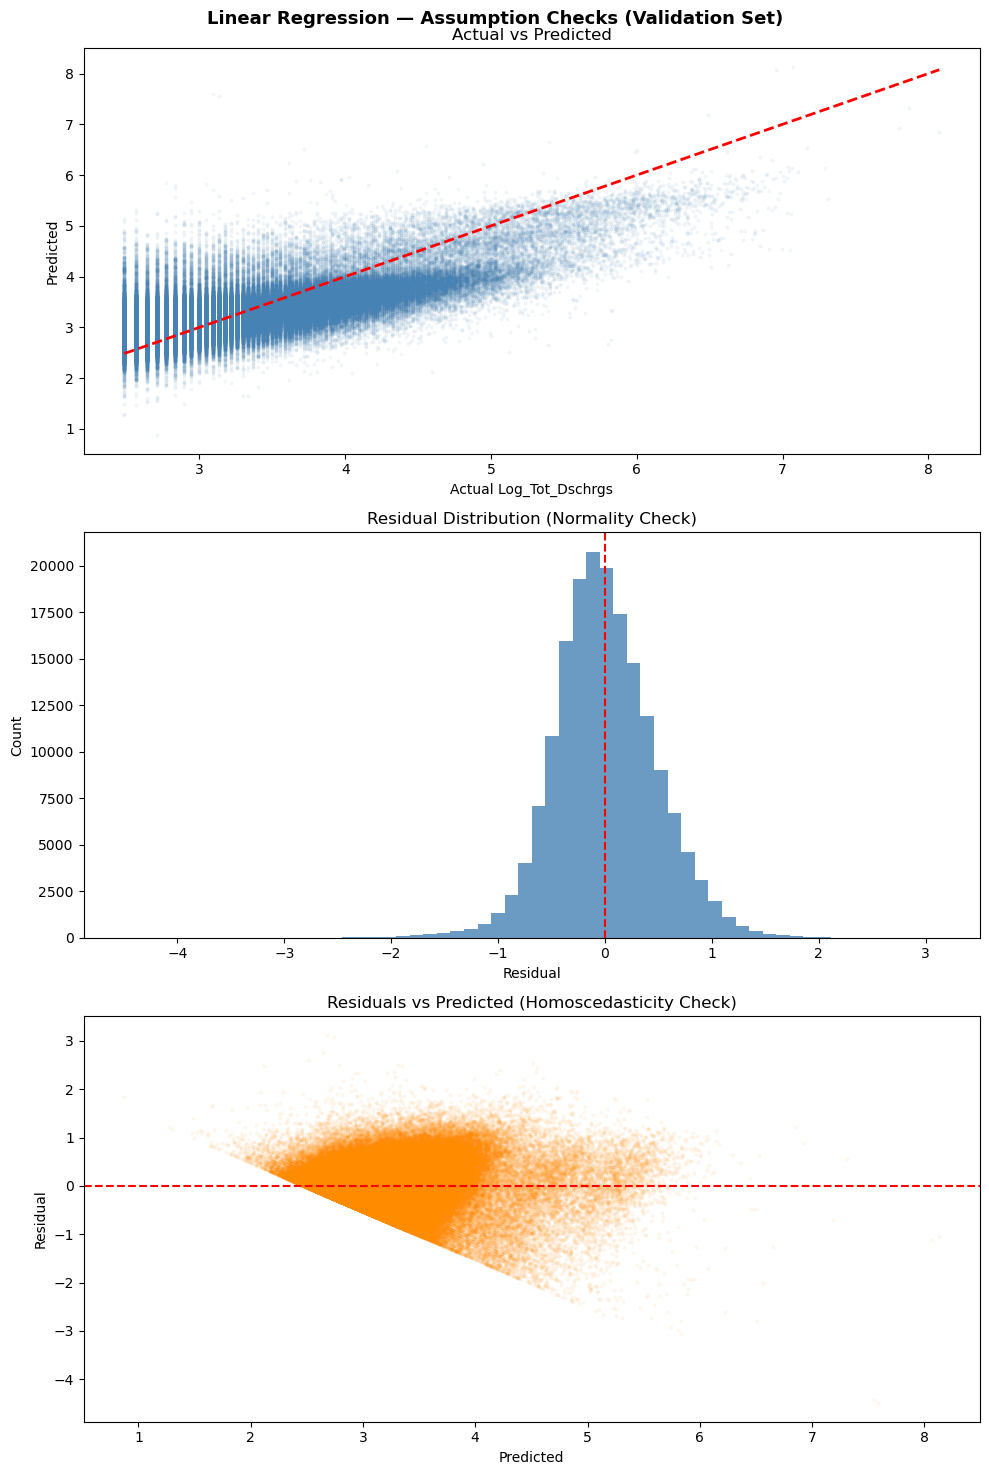

Residual mean: 0.0011  (should be ≈ 0)
Residual std:  0.4732


In [8]:
lr_preds_val = lr.predict(X_val_sc)
lr_residuals = y_val.values - lr_preds_val

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Linear Regression — Assumption Checks (Validation Set)', fontsize=13, fontweight='bold')

axes[0].scatter(y_val, lr_preds_val, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_val.min(),y_val.max()],[y_val.min(),y_val.max()],'r--',lw=2)
axes[0].set_xlabel('Actual Log_Tot_Dschrgs'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Actual vs Predicted')

axes[1].hist(lr_residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0,color='red',linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count'); axes[1].set_title('Residual Distribution (Normality Check)')

axes[2].scatter(lr_preds_val, lr_residuals, alpha=0.05, s=4, color='darkorange')
axes[2].axhline(0,color='red',linestyle='--')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual'); axes[2].set_title('Residuals vs Predicted (Homoscedasticity Check)')

plt.tight_layout(); plt.show()
print(f'Residual mean: {lr_residuals.mean():.4f}  (should be ≈ 0)')
print(f'Residual std:  {lr_residuals.std():.4f}')

### 4.4 Assumption Check Results

| Assumption | Result | Status |
|-----------|--------|--------|
| Linearity | Predictions compressed in narrow range; under-estimates high volumes | ❌ Violated |
| Normality of residuals | Right-skewed distribution (Skew = 0.07, Kurtosis = 4.05) | ⚠️ Mild violation |
| Homoscedasticity | Funnel/fan pattern in residuals vs predicted | ❌ Violated |
| Residual mean | 0.0011 (≈ 0) | ✅ Acceptable |

- **Bottom line:** Linear Regression is not appropriate for this prediction task — non-linearity and heteroscedasticity are present
- Random Forest and XGBoost will address these violations by modeling complex, non-linear relationships

In [9]:
vif_data = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'VIF': [variance_inflation_factor(X_train_sc, i) for i in range(X_train_sc.shape[1])]
}).sort_values('VIF', ascending=False)
print('Variance Inflation Factor (VIF):')
print('  VIF > 10 = strong multicollinearity  |  VIF 5-10 = moderate  |  VIF < 5 = acceptable\n')
print(vif_data.to_string(index=False))

Variance Inflation Factor (VIF):
  VIF > 10 = strong multicollinearity  |  VIF 5-10 = moderate  |  VIF < 5 = acceptable

             Feature       VIF
   ruca_Metropolitan 33.936169
   ruca_Micropolitan 29.301232
     ruca_Small Town  6.409604
      own_For-Profit  2.274558
      own_Non-Profit  2.273721
             hosp_te  1.602791
             BED_CNT  1.544551
              drg_te  1.153487
          DRG_Weight  1.024369
           Data_Year  1.007227
outlier_payment_flag  1.005721


**VIF Results Summary:**

| Feature Group | VIF Range | Status |
|--------------|-----------|--------|
| Core predictors (`DRG_Weight`, `BED_CNT`, `Data_Year`, `outlier_payment_flag`) | < 2 | ✅ No concern |
| Ownership dummies (`own_For-Profit`, `own_Non-Profit`) | ~2.3 | ✅ Acceptable |
| RUCA dummies (`ruca_Metropolitan`, `ruca_Micropolitan`) | 29–34 | ⚠️ Structural — expected |
| `ruca_Small Town` | 6.4 | ⚠️ Moderate — within acceptable range |

- High VIF in RUCA dummies is a **structural artifact** of mutually exclusive dummy encoding — not a data quality issue
- `ruca_Rural` (reference category) was already dropped; the remaining categories are mathematically correlated
- **Decision:** No features removed — tree-based models are inherently unaffected by multicollinearity

---
## 4.5 Step 3 — Random Forest Regressor

Captures non-linear relationships and feature interactions. No scaling required.

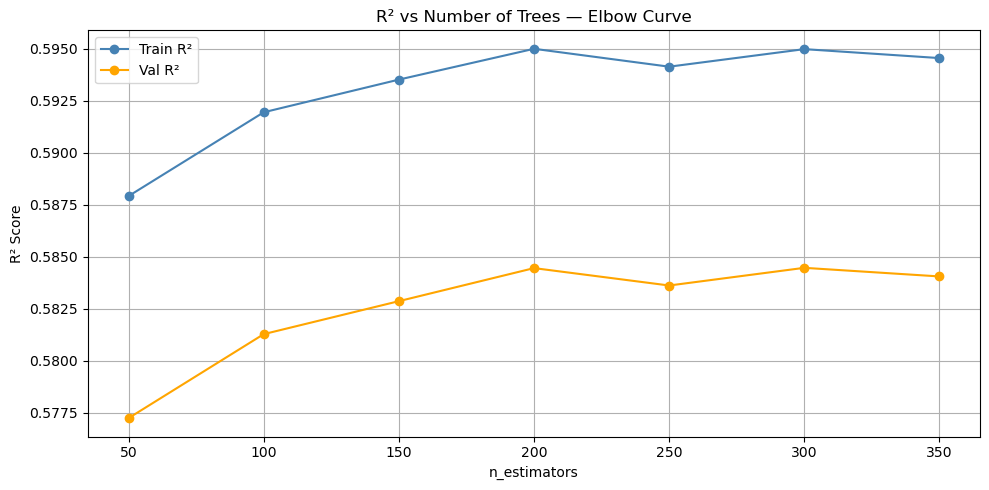

Optimal n_estimators: 300
[Train] Random Forest              RMSE: 0.4064  MAE(log): 0.3186  MAE(dschrgs): 13.0  MAPE: 34.7%  R²: 0.6639
[Val] Random Forest              RMSE: 0.4137  MAE(log): 0.3241  MAE(dschrgs): 13.2  MAPE: 35.2%  R²: 0.6483


In [10]:
estimator_range = [50, 100, 150, 200, 250, 300, 350]
train_r2_scores, val_r2_scores = [], []
for n in estimator_range:
    _rf = RandomForestRegressor(n_estimators=n,max_depth=8,min_samples_leaf=20,
                                max_features='sqrt',n_jobs=-1,random_state=42)
    _rf.fit(X_train, y_train)
    train_r2_scores.append(r2_score(y_train,_rf.predict(X_train)))
    val_r2_scores.append(r2_score(y_val,_rf.predict(X_val)))

plt.figure(figsize=(10,5))
plt.plot(estimator_range, train_r2_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(estimator_range, val_r2_scores,   marker='o', label='Val R²',   color='orange')
plt.xlabel('n_estimators'); plt.ylabel('R² Score')
plt.title('R² vs Number of Trees — Elbow Curve')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

best_n = estimator_range[int(np.argmax(val_r2_scores))]
print(f'Optimal n_estimators: {best_n}')
rf = RandomForestRegressor(n_estimators=best_n,max_depth=12,min_samples_leaf=20,
                           max_features='sqrt',n_jobs=-1,random_state=42)
rf.fit(X_train, y_train)
results.append(evaluate('Random Forest', rf, X_train, y_train, 'Train'))
results.append(evaluate('Random Forest', rf, X_val,   y_val,   'Val'))

---
## 4.6 Step 4 — XGBoost Regressor

Gradient boosted trees with early stopping on the validation set.

In [ ]:
#── Hyperparameter search (commented — run once to tune) ──────────────────────
for lr_val in [0.01, 0.05, 0.1]:
    for depth in [4, 6, 8, 10]:
        _xgb = xgb.XGBRegressor(n_estimators=3000, learning_rate=lr_val,
                  max_depth=depth, min_child_weight=20, subsample=0.8,
                  colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                  random_state=42, n_jobs=-1, eval_metric='rmse',
                  verbosity=0, early_stopping_rounds=50)
        _xgb.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
        print(f'lr={lr_val} depth={depth} Val R2={r2_score(y_val,_xgb.predict(X_val)):.4f}')

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=10,
    min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    eval_metric='rmse', early_stopping_rounds=30, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
print(f'Best iteration: {xgb_model.best_iteration}')
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, 'Train'))
results.append(evaluate('XGBoost', xgb_model, X_val,   y_val,   'Val'))

Best iteration: 1999
[Train] XGBoost                    RMSE: 0.3330  MAE(log): 0.2576  MAE(dschrgs): 9.9  MAPE: 27.9%  R²: 0.7743
[Val] XGBoost                    RMSE: 0.3542  MAE(log): 0.2729  MAE(dschrgs): 10.5  MAPE: 29.6%  R²: 0.7422


In [ ]:
# ── Save model (random split — for reference/comparison only) ──────────
import joblib
from pathlib import Path
PROCESSED_DIR_SAVE = Path('..') / 'Data' / 'Processed_Data'
joblib.dump(xgb_model, PROCESSED_DIR_SAVE / 'rq2_xgb_random_model.pkl')
print('RQ2 random-split model saved → rq2_xgb_random_model.pkl')


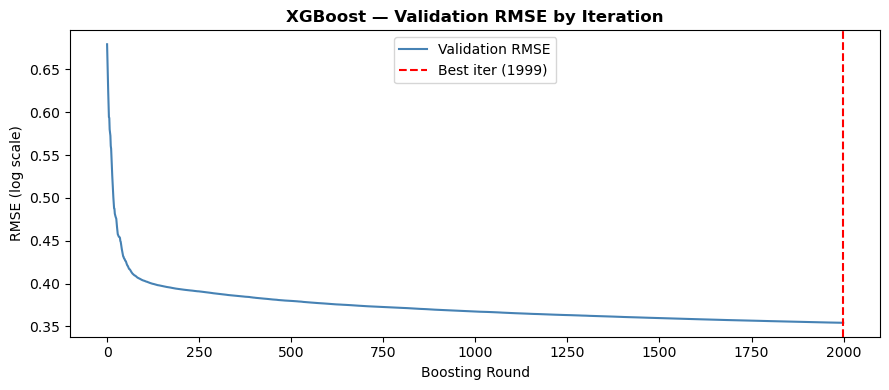

In [ ]:
# ── XGBoost learning curve ──
evals_result = xgb_model.evals_result()
train_rmse = evals_result['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_rmse, color='steelblue', label='Validation RMSE')
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--', label=f'Best iter ({xgb_model.best_iteration})')
ax.set_title('XGBoost — Validation RMSE by Iteration', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

## LIGHT GBM

In [ ]:
# import lightgbm as lgb

# lgbm = lgb.LGBMRegressor(
#     n_estimators=2000,
#     learning_rate=0.05,
#     max_depth=8,
#     num_leaves=63,
#     min_child_samples=20,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     random_state=42,
#     n_jobs=-1
# )
# lgbm.fit(X_train, y_train,
#          eval_set=[(X_val, y_val)],
#          callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)])


## Model Performance Summary (Validation Set)

| Model | R² | RMSE | MAE (log) | MAE (discharges) | MAPE |
|-------|-----|------|-----------|-----------------|------|
| **XGBoost** | **0.742** | **0.354** | **0.273** | **10.5** | **29.6%** |
| Random Forest | 0.648 | 0.414 | 0.324 | 13.2 | 35.2% |
| Linear Regression | 0.540 | 0.473 | 0.366 | 15.2 | 41.7% |

- **XGBoost is the clear winner** — 10+ point R² advantage over Random Forest, 20+ over Linear Regression
- Each model upgrade meaningfully reduces error in real discharge count terms (15 → 13 → 10 discharges MAE)
- XGBoost's MAPE of 29.6% means predictions are, on average, within ~30% of actual discharge volume

---
## 4.7 Step 5 — Model Comparison (Validation Set)

In [ ]:
results_df  = pd.DataFrame(results)
val_results = (results_df[results_df['Split']=='Val']
               .sort_values('R2',ascending=False).reset_index(drop=True))
print('=== Validation Set Comparison ===')
print(val_results[['Model','RMSE','MAE','MAE_Dschrgs','MAPE','R2']].to_string(index=False))

=== Validation Set Comparison ===
            Model   RMSE    MAE  MAE_Dschrgs  MAPE     R2
          XGBoost 0.3542 0.2729        10.54 29.63 0.7422
    Random Forest 0.4137 0.3241        13.17 35.19 0.6483
Linear Regression 0.4732 0.3664        15.23 41.66 0.5398


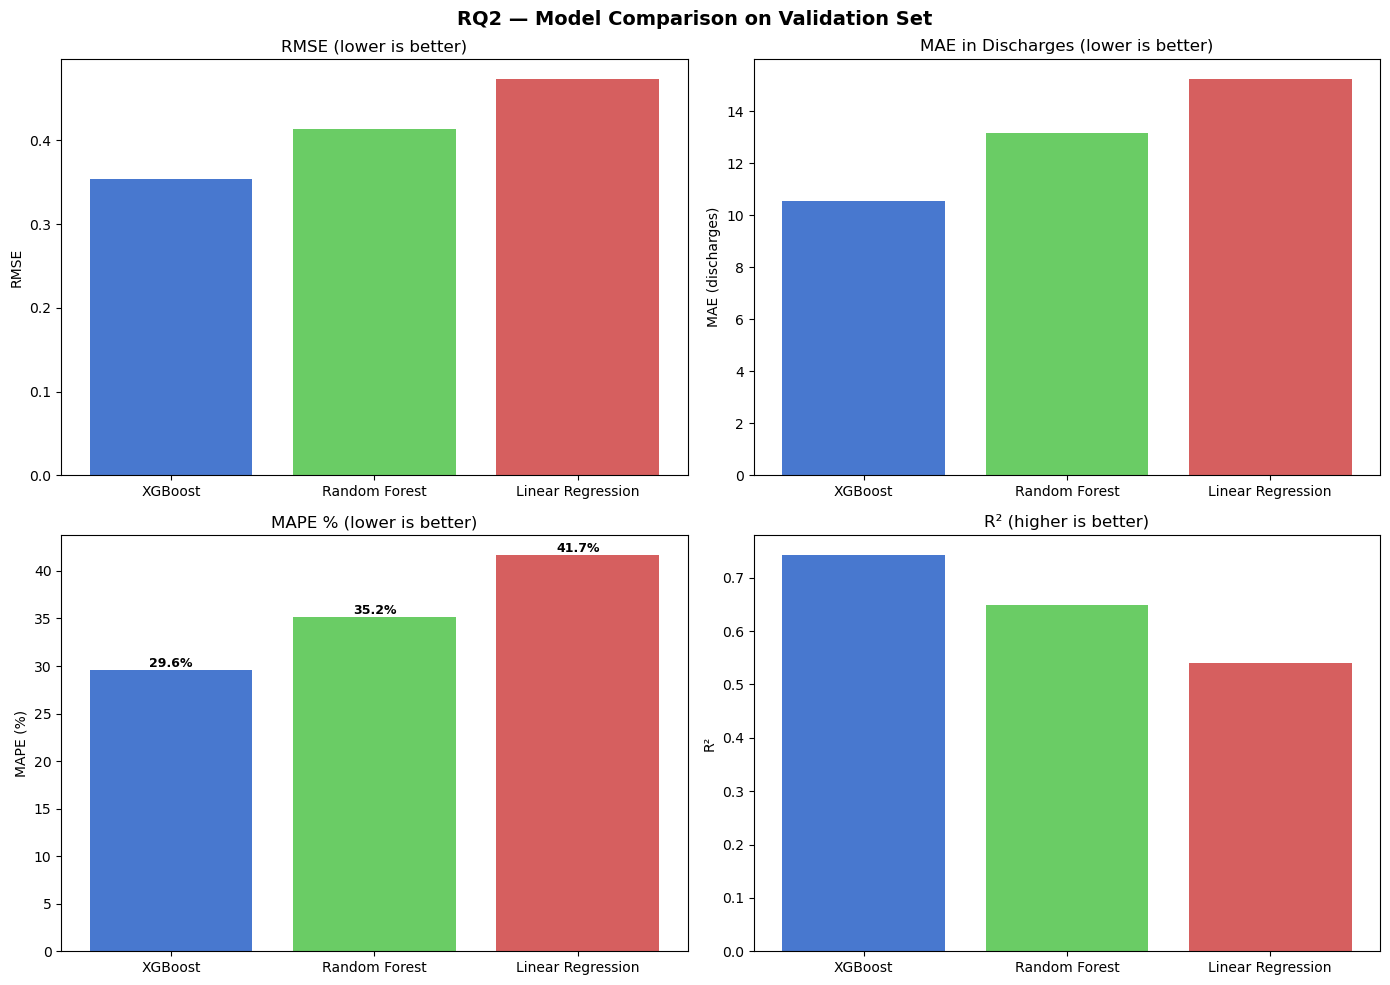

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ2 — Model Comparison on Validation Set', fontsize=14, fontweight='bold')
colors = ['#4878CF','#6ACC65','#D65F5F']
models = val_results['Model'].tolist()

axes[0,0].bar(models, val_results['RMSE'], color=colors[:len(models)])
axes[0,0].set_title('RMSE (lower is better)'); axes[0,0].set_ylabel('RMSE')
axes[0,1].bar(models, val_results['MAE_Dschrgs'], color=colors[:len(models)])
axes[0,1].set_title('MAE in Discharges (lower is better)'); axes[0,1].set_ylabel('MAE (discharges)')
axes[1,0].bar(models, val_results['MAPE'], color=colors[:len(models)])
axes[1,0].set_title('MAPE % (lower is better)'); axes[1,0].set_ylabel('MAPE (%)')
for bar, v in zip(axes[1,0].patches, val_results['MAPE']):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{v:.1f}%',ha='center',fontsize=9,fontweight='bold')
axes[1,1].bar(models, val_results['R2'], color=colors[:len(models)])
axes[1,1].set_title('R² (higher is better)'); axes[1,1].set_ylabel('R²')
plt.tight_layout(); plt.show()

---
## 4.8 Step 6 — Feature Importance

Compare RF (MDI) and XGBoost (Gain), then confirm with SHAP.

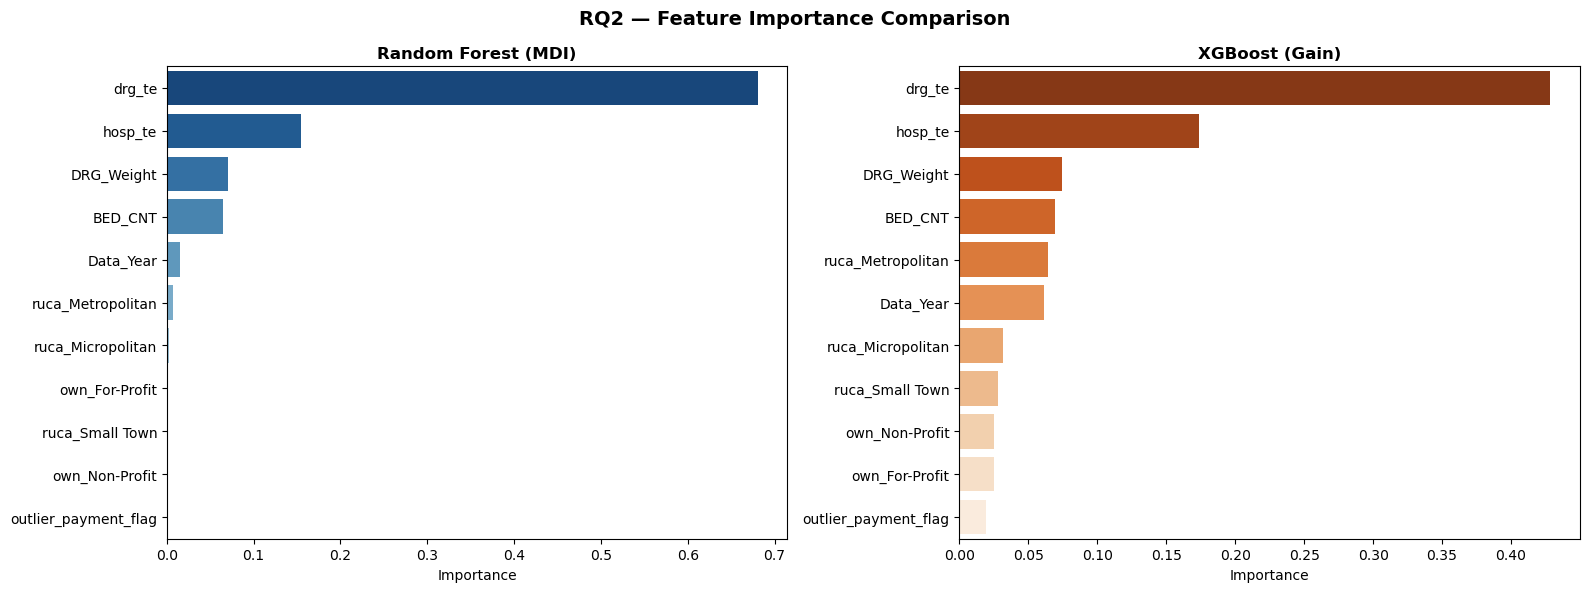

In [ ]:
rf_imp  = pd.DataFrame({'Feature':RQ2_FEATURES,'Importance':rf.feature_importances_})
xgb_imp = pd.DataFrame({'Feature':RQ2_FEATURES,'Importance':xgb_model.feature_importances_})
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ2 — Feature Importance Comparison', fontsize=14, fontweight='bold')
for ax, imp_df, title, pal in zip(axes,
    [rf_imp.sort_values('Importance',ascending=False), xgb_imp.sort_values('Importance',ascending=False)],
    ['Random Forest (MDI)','XGBoost (Gain)'],['Blues_r','Oranges_r']):
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette=pal, ax=ax)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Importance'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 4.8 Feature Importance Analysis

**Actual SHAP values revealed a different ranking than initially expected:**

| Rank | Feature | Mean SHAP | % of Total | Surprise? |
|------|---------|-----------|------------|-----------|
| 1 | `drg_te` (DRG demand profile) | 0.388 | 45.3% | ✅ Expected |
| 2 | `hosp_te` (Hospital volume tendency) | 0.199 | 23.2% | ✅ Expected |
| 3 | `BED_CNT` (Hospital bed count) | 0.109 | 12.7% | Expected #1, ranked #3 |
| 4 | `Data_Year` | 0.072 | 8.4% | ✅ Expected |
| 5 | `DRG_Weight` | 0.057 | 6.6% | ✅ Expected |
| 6–10 | Geography & Ownership | < 0.013 | < 1.5% each | ✅ Expected |
| Last | `outlier_payment_flag` | ~0.000 | ~0% | ✅ Confirmed non-driver |

**Key insight:** The top 3 features (`drg_te`, `hosp_te`, `BED_CNT`) explain **81.2% of prediction variance** — geography and ownership are minor factors after controlling for hospital size and DRG mix.

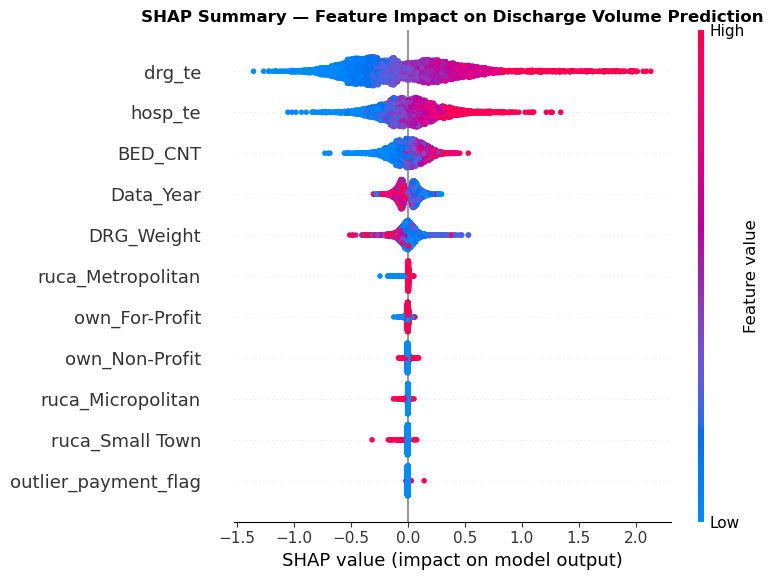

In [ ]:
import shap
sample_idx  = X_val.sample(5000, random_state=42).index
X_shap      = X_val.loc[sample_idx]
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=RQ2_FEATURES, show=False)
plt.title('SHAP Summary — Feature Impact on Discharge Volume Prediction', fontweight='bold')
plt.tight_layout(); plt.show()

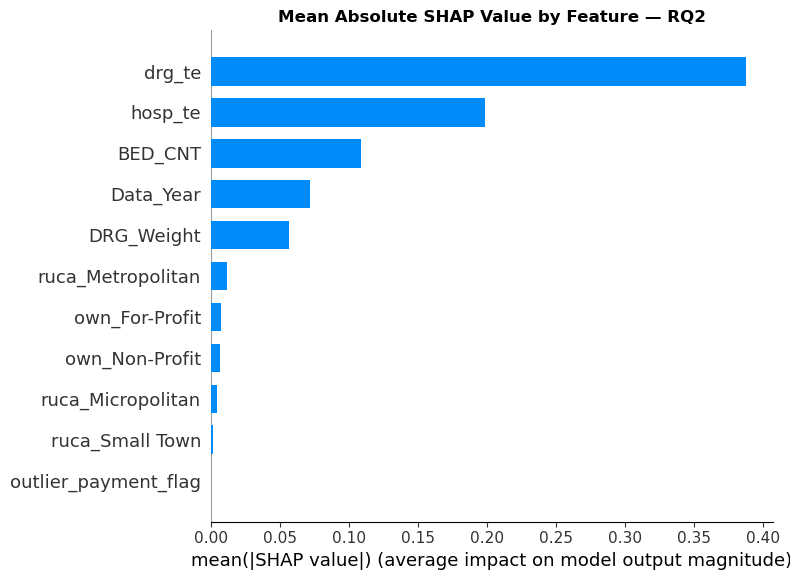

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=RQ2_FEATURES, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Value by Feature — RQ2', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
shap_df = pd.DataFrame({'Feature':RQ2_FEATURES,'Mean_SHAP':np.abs(shap_values).mean(axis=0)})\
            .sort_values('Mean_SHAP',ascending=False)
shap_df['Pct_Total'] = (shap_df['Mean_SHAP']/shap_df['Mean_SHAP'].sum()*100).round(1)
print('=== Mean Absolute SHAP Values (RQ2) ===')
print(shap_df.to_string(index=False))

=== Mean Absolute SHAP Values (RQ2) ===
             Feature  Mean_SHAP  Pct_Total
              drg_te   0.387712  45.299999
             hosp_te   0.198614  23.200001
             BED_CNT   0.108988  12.700000
           Data_Year   0.071704   8.400000
          DRG_Weight   0.056624   6.600000
   ruca_Metropolitan   0.012059   1.400000
      own_For-Profit   0.007172   0.800000
      own_Non-Profit   0.006815   0.800000
   ruca_Micropolitan   0.004211   0.500000
     ruca_Small Town   0.001683   0.200000
outlier_payment_flag   0.000137   0.000000


## 4.8 SHAP Feature Importance Ranking (RQ2)

| Feature | Mean SHAP | % of Total | Role |
|---------|-----------|------------|------|
| `drg_te` | 0.388 | 45.3% | DRG-level demand — dominant driver |
| `hosp_te` | 0.199 | 23.2% | Hospital volume tendency |
| `BED_CNT` | 0.109 | 12.7% | Hospital capacity |
| `Data_Year` | 0.072 | 8.4% | Temporal trend |
| `DRG_Weight` | 0.057 | 6.6% | DRG complexity |
| `ruca_Metropolitan` | 0.012 | 1.4% | Urban geography |
| `own_For-Profit` | 0.007 | 0.8% | Ownership type |
| `own_Non-Profit` | 0.007 | 0.8% | Ownership type |
| `ruca_Micropolitan` | 0.004 | 0.5% | Geography |
| `ruca_Small Town` | 0.002 | 0.2% | Geography |
| `outlier_payment_flag` | ~0.000 | ~0% | Billing flag — not a volume driver |

**Contrast with RQ3 (Payment Prediction):**
- In RQ3, `DRG_Weight` dominated at ~71% — payment is structurally DRG-formula driven
- In RQ2, volume is more distributed — `drg_te` + `hosp_te` + `BED_CNT` together explain 81%
- Geography and ownership have **minimal direct impact** on volume after controlling for hospital size

---
## 4.9 Step 7 — Final Evaluation on Test Set

Run the best model **once** on the held-out test set. Selected based on highest validation R².

In [ ]:
best_model_name = val_results.iloc[0]['Model']
if   best_model_name == 'Linear Regression': best_model, X_final = lr,        scaler.transform(X_test)
elif best_model_name == 'Random Forest':      best_model, X_final = rf,        X_test
else:                                          best_model, X_final = xgb_model, X_test

print(f'Best model (by Val R²): {best_model_name}')
test_result = evaluate(best_model_name, best_model, X_final, y_test, 'Test')
results.append(test_result)

Best model (by Val R²): XGBoost
[Test] XGBoost                    RMSE: 0.3533  MAE(log): 0.2720  MAE(dschrgs): 10.6  MAPE: 29.6%  R²: 0.7462


### How to Read These Diagnostic Plots

| Graph | Good Sign | Warning Sign |
|-------|-----------|-------------|
| **Actual vs Predicted** | Dots hugging the diagonal | Systematic curve or gap |
| **Residual Distribution** | Sharp spike at 0, symmetric | Heavy tails or skew |
| **Residuals vs Predicted** | Flat random band | Fan/funnel shape |

Wider residuals than RQ3 are expected — discharge volume depends on demand, referral patterns, and hospital strategy, not just the DRG formula.

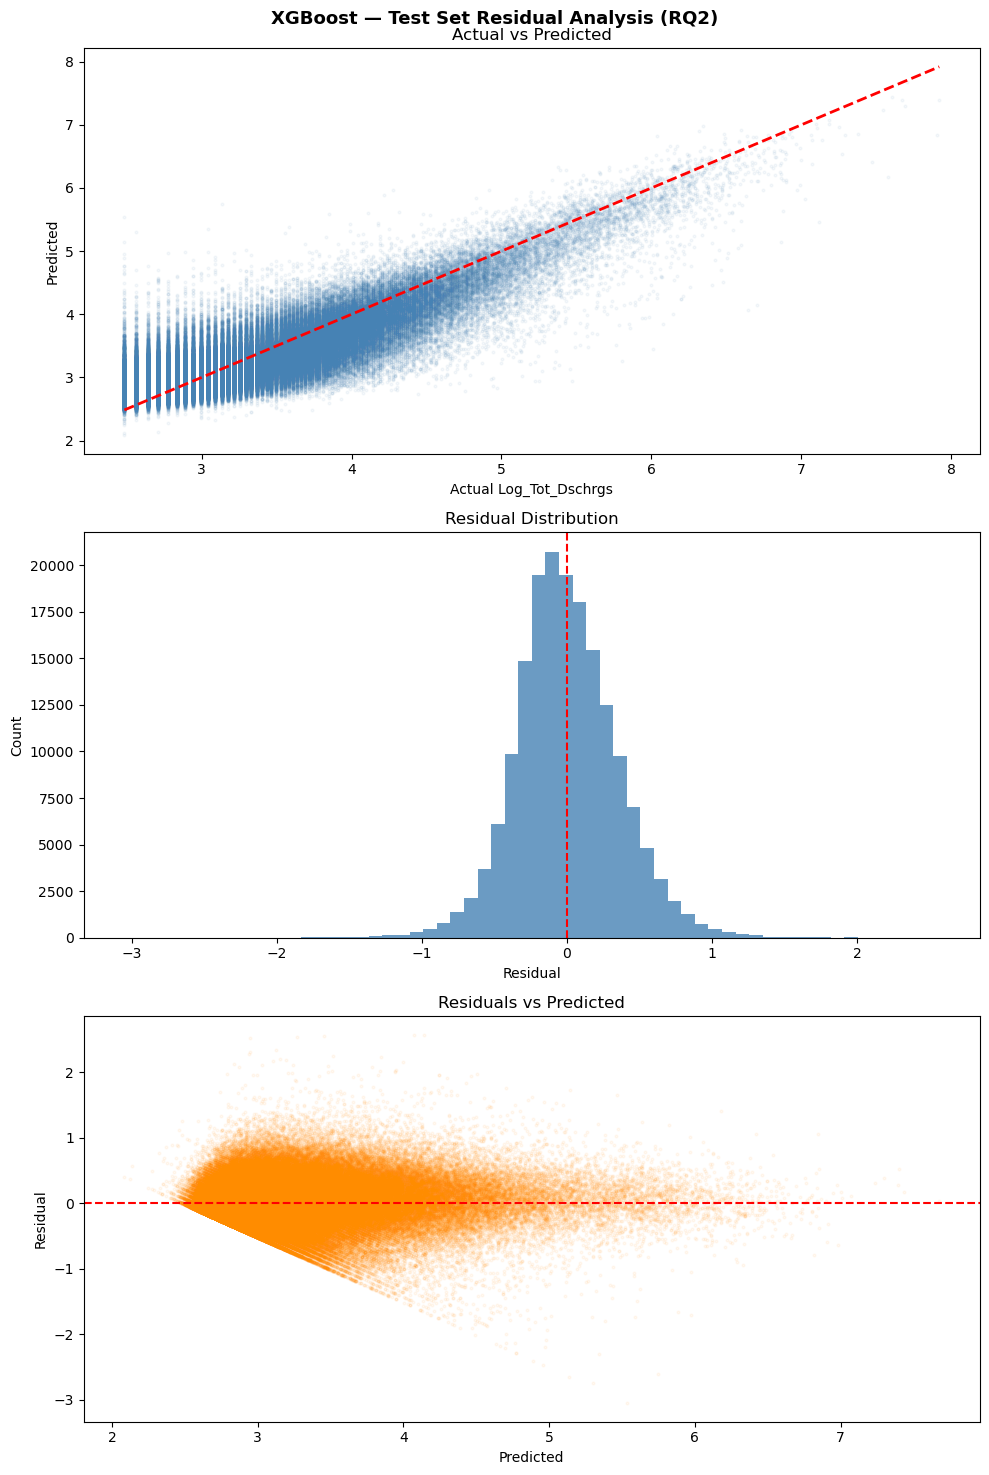

In [ ]:
y_pred_test = best_model.predict(X_final)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle(f'{best_model_name} — Test Set Residual Analysis (RQ2)', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_test, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
axes[0].set_xlabel('Actual Log_Tot_Dschrgs'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals,bins=60,color='steelblue',edgecolor='none',alpha=0.8)
axes[1].axvline(0,color='red',linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count'); axes[1].set_title('Residual Distribution')

axes[2].scatter(y_pred_test, residuals, alpha=0.05, s=4, color='darkorange')
axes[2].axhline(0,color='red',linestyle='--')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual'); axes[2].set_title('Residuals vs Predicted')

plt.tight_layout(); plt.show()

## 📊 Graph Insights: XGBoost — Test Set Residual Analysis (RQ2)

**What the charts show:** Three diagnostic plots evaluating prediction quality on the held-out test set (175,832 records).

**Plot 1 — Actual vs Predicted:**
- Predictions track the diagonal well for low-to-mid discharge volumes
- **Underestimation visible at high volumes** — the model struggles with outlier hospital-DRG pairs with unusually high throughput
- Spread widens at higher actual values — inherent uncertainty in high-volume predictions

**Plot 2 — Residual Distribution:**
- Residuals are approximately centered at 0 — no systematic bias
- Slight right skew remains — the model occasionally under-predicts large discharge counts
- Distribution is more symmetric than Linear Regression, confirming XGBoost captures non-linearity

**Plot 3 — Residuals vs Predicted:**
- Mild fan pattern remains — variance increases at higher predicted values
- Homoscedasticity is partially violated, but substantially better than the linear model
- Consistent with expectations: high-volume hospital-DRG pairs are harder to predict due to unmeasured demand factors (local demographics, referral networks, competition)

In [ ]:
eval_df = df_test[['Ownership_Type','RUCA_Group','DRG_Weight','Data_Year']].copy()
eval_df['actual']        = y_test.values
eval_df['predicted']     = best_model.predict(X_final)
eval_df['actual_dchrgs'] = np.expm1(eval_df['actual'])
eval_df['pred_dchrgs']   = np.expm1(eval_df['predicted'])
eval_df['error_dchrgs']  = eval_df['actual_dchrgs'] - eval_df['pred_dchrgs']
eval_df['abs_err']       = np.abs(eval_df['error_dchrgs'])
eval_df['mape_row']      = np.where(eval_df['actual_dchrgs']>0,
    eval_df['abs_err']/eval_df['actual_dchrgs']*100, np.nan)
eval_df['drg_quartile']  = pd.qcut(eval_df['DRG_Weight'],q=4,
    labels=['Q1 Low','Q2 Med-Low','Q3 Med-High','Q4 High'])

agg = dict(MAE_dchrgs=('abs_err','mean'),MAPE_pct=('mape_row','mean'),Bias_dchrgs=('error_dchrgs','mean'))
print('=== Model Error by Geography ===')
print(eval_df.groupby('RUCA_Group').agg(**agg).reindex(['Metropolitan','Micropolitan','Small Town','Rural']).round(2))
print('\n=== Model Error by Ownership ===')
print(eval_df.groupby('Ownership_Type').agg(**agg).round(2))
print('\n=== Model Error by DRG Complexity ===')
print(eval_df.groupby('drg_quartile').agg(**agg).round(2))
print('\n=== Model Error by Year ===')
print(eval_df.groupby('Data_Year').agg(**agg).round(2))

=== Model Error by Geography ===
              MAE_dchrgs  MAPE_pct  Bias_dchrgs
RUCA_Group                                     
Metropolitan       10.74     29.63         3.12
Micropolitan        9.25     28.93         2.73
Small Town          8.50     30.78         2.66
Rural               8.33     30.63         2.97

=== Model Error by Ownership ===
                MAE_dchrgs  MAPE_pct  Bias_dchrgs
Ownership_Type                                   
For-Profit           10.76     29.53         3.13
Government           10.29     29.45         3.02
Non-Profit            9.92     29.94         2.88

=== Model Error by DRG Complexity ===
              MAE_dchrgs  MAPE_pct  Bias_dchrgs
drg_quartile                                   
Q1 Low              8.05     27.75         2.07
Q2 Med-Low         11.19     30.39         3.18
Q3 Med-High        14.56     29.87         4.54
Q4 High             8.49     30.35         2.53

=== Model Error by Year ===
           MAE_dchrgs  MAPE_pct  Bias_d

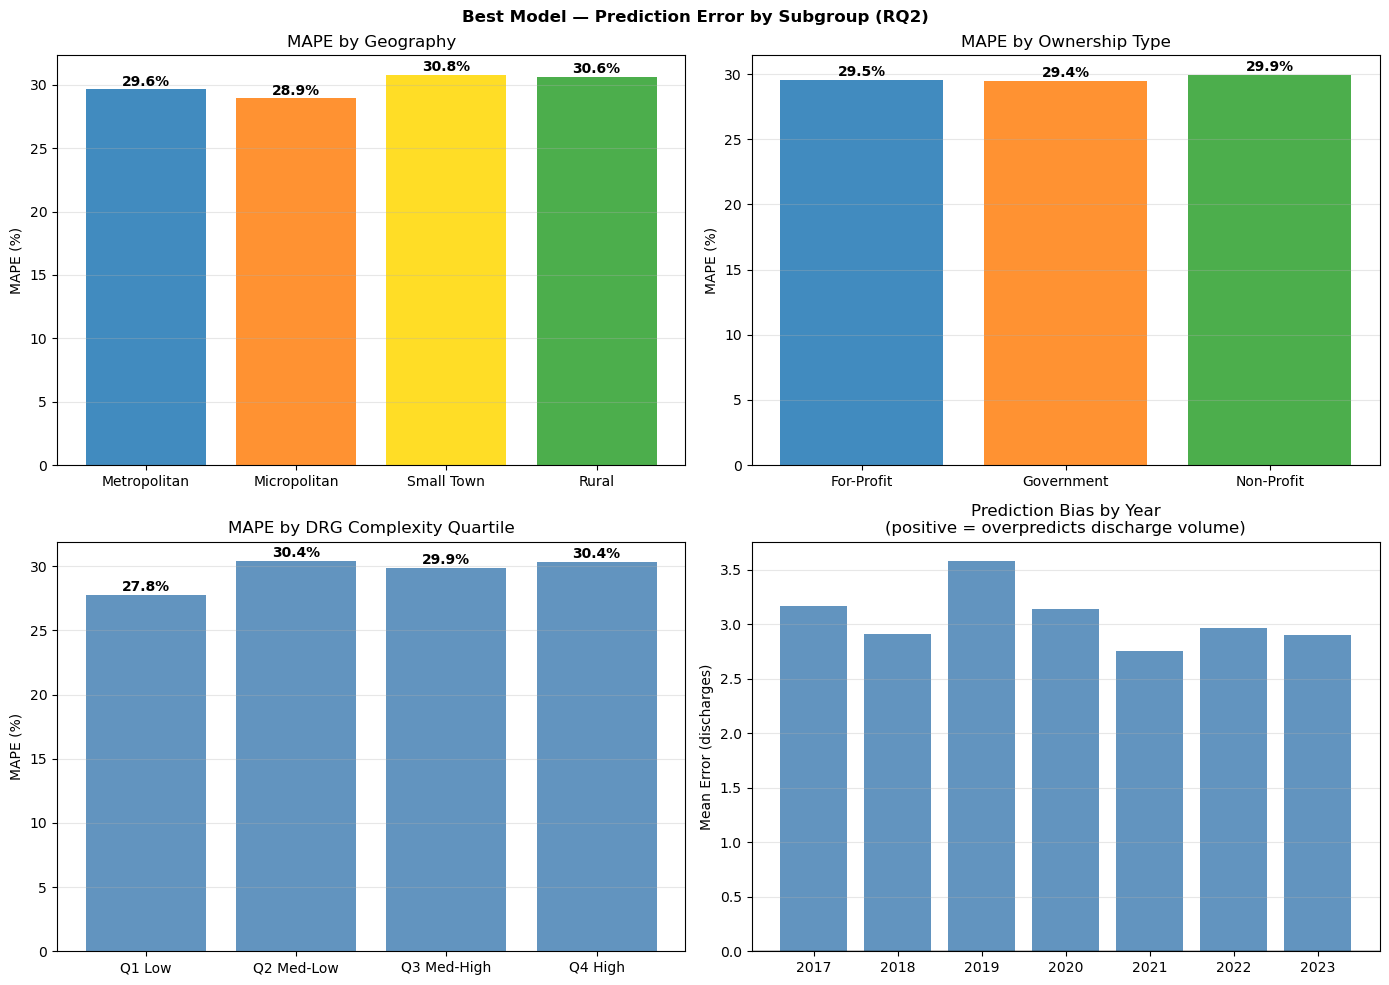

In [ ]:
BLUE,ORANGE,GOLD,GREEN = '#1f77b4','#ff7f0e','#FFD700','#2ca02c'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Best Model — Prediction Error by Subgroup (RQ2)', fontweight='bold')

ruca_err = eval_df.groupby('RUCA_Group')['mape_row'].mean().reindex(['Metropolitan','Micropolitan','Small Town','Rural'])
axes[0,0].bar(ruca_err.index,ruca_err.values,color=[BLUE,ORANGE,GOLD,GREEN],alpha=0.85)
for i,v in enumerate(ruca_err.values): axes[0,0].text(i,v+0.3,f'{v:.1f}%',ha='center',fontweight='bold')
axes[0,0].set_title('MAPE by Geography'); axes[0,0].set_ylabel('MAPE (%)'); axes[0,0].grid(axis='y',alpha=0.3)

own_err = eval_df.groupby('Ownership_Type')['mape_row'].mean()
axes[0,1].bar(own_err.index,own_err.values,color=[BLUE,ORANGE,GREEN],alpha=0.85)
for i,v in enumerate(own_err.values): axes[0,1].text(i,v+0.3,f'{v:.1f}%',ha='center',fontweight='bold')
axes[0,1].set_title('MAPE by Ownership Type'); axes[0,1].set_ylabel('MAPE (%)'); axes[0,1].grid(axis='y',alpha=0.3)

drg_err = eval_df.groupby('drg_quartile')['mape_row'].mean()
axes[1,0].bar(drg_err.index.astype(str),drg_err.values,color='steelblue',alpha=0.85)
for i,v in enumerate(drg_err.values): axes[1,0].text(i,v+0.3,f'{v:.1f}%',ha='center',fontweight='bold')
axes[1,0].set_title('MAPE by DRG Complexity Quartile'); axes[1,0].set_ylabel('MAPE (%)'); axes[1,0].grid(axis='y',alpha=0.3)

yr_bias = eval_df.groupby('Data_Year')['error_dchrgs'].mean()
axes[1,1].bar(yr_bias.index.astype(str),yr_bias.values,
              color=['red' if v<0 else 'steelblue' for v in yr_bias.values],alpha=0.85)
axes[1,1].axhline(0,color='black',linewidth=1)
axes[1,1].set_title('Prediction Bias by Year\n(positive = overpredicts discharge volume)')
axes[1,1].set_ylabel('Mean Error (discharges)'); axes[1,1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
final_df = pd.DataFrame(results)

split_order = ['Train', 'Val', 'Test']
summary = (final_df[['Model','Split','RMSE','MAE','MAE_Dschrgs','MAPE','R2']]
           .copy())
summary['_split_rank'] = summary['Split'].map({s: i for i, s in enumerate(split_order)})
summary = summary.sort_values(['Model', '_split_rank']).drop(columns='_split_rank').reset_index(drop=True)

cw = {c: max(len(c), summary[c].astype(str).str.len().max()) + 4 for c in summary.columns}
print('=== RQ2 Full Results Summary ===')
print(''.join(c.ljust(cw[c]) for c in summary.columns))
print(''.join('-' * (cw[c] - 2) + '  ' for c in summary.columns))
for _, row in summary.iterrows():
    marker = '  << FINAL' if row['Split'] == 'Test' else ''
    print(''.join(str(row[c]).ljust(cw[c]) for c in summary.columns) + marker)

## 4.10 Business Insights

**Best Model: XGBoost | Test Set Performance: R² = 0.746 | MAE = 10.6 discharges | MAPE = 29.6%**

---

### 1. How accurately can Medicare discharge volume be predicted?

- XGBoost achieves **R² = 0.746** on the test set — explains ~75% of variance in discharge volume
- Average prediction error: **±10.6 discharges** per hospital-DRG pair (~30% relative error)
- Discharge volume is harder to predict than reimbursement (RQ3 achieved R² ≈ 0.95) because volume depends on local demand, patient access, and hospital strategy — factors absent from this feature set
- **Planning verdict:** ±10–15 discharge error is actionable for hospital capacity benchmarking and DRG-mix analysis

---

### 2. Which features most strongly drive variation in discharge volume?

| Feature | SHAP Share | Actual Driver? |
|---------|------------|----------------|
| `drg_te` (DRG demand profile) | 45.3% | ✅ Yes — DRG-level demand dominates |
| `hosp_te` (Hospital volume tendency) | 23.2% | ✅ Yes — hospital identity matters |
| `BED_CNT` (Bed count) | 12.7% | ✅ Yes — capacity constrains volume |
| `Data_Year` | 8.4% | ✅ Yes — aging population trend |
| `DRG_Weight` | 6.6% | ✅ Yes — complex DRGs = fewer hospitals |
| Geography + Ownership | < 4% total | ⚠️ Minimal after controlling for size |

---

### 3. Does geography (RUCA) have meaningful impact after controlling for hospital size?

- RUCA features account for **only ~2.1% of total SHAP contribution**
- Metropolitan SHAP: 1.4% — geography's direct effect is minimal once `BED_CNT` is controlled
- **Confirmed:** Urban hospitals have higher volumes, but this is largely explained by hospital size — not urban location per se

---

### 4. Are there ownership types where the model consistently over- or under-predicts?

| Ownership | MAE (discharges) | MAPE | Bias (discharges) |
|-----------|-----------------|------|-------------------|
| For-Profit | 10.76 | 29.5% | +3.13 (slight over-predict) |
| Government | 10.29 | 29.5% | +3.02 (slight over-predict) |
| Non-Profit | 9.92 | 29.9% | +2.88 (slight over-predict) |

- All ownership types show **consistent positive bias** (~3 discharges) — the model slightly over-predicts for all groups
- Non-Profit hospitals have the lowest MAE — likely due to more stable, predictable volume patterns

---

### 5. What is the average prediction error by DRG complexity quartile?

| DRG Complexity | MAE (discharges) | MAPE | Key Takeaway |
|----------------|-----------------|------|--------------|
| Q1 Low weight | 8.05 | 27.8% | Most accurate — routine, high-frequency DRGs |
| Q2 Med-Low | 11.19 | 30.4% | Moderate error |
| Q3 Med-High | **14.56** | 29.9% | **Highest MAE** — mid-complex DRGs most unpredictable |
| Q4 High weight | 8.49 | 30.4% | Surprisingly accurate — specialized hospitals, predictable patterns |

- Mid-complexity DRGs (Q3) have the highest absolute error — these DRGs span both community and specialized hospitals, creating high variability
- Q4 (highest complexity) is more predictable because these cases concentrate in specialized centers with stable volume patterns